<a href="https://colab.research.google.com/github/amit-sw/colab_notebooks/blob/main/20260831_Chatbot_OpenAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up

In [1]:
!pip install openai langgraph pydantic --quiet

In [19]:
from IPython.display import display, Markdown
from openai import OpenAI
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
import json

In [3]:
import os
from google.colab import userdata

OPENAI_API_KEY=userdata.get('OPENAI_API_KEY')
OPENAI_MODEL='gpt-5.6-luna'
os.environ['OPENAI_API_KEY']=OPENAI_API_KEY


# Single message : Request-response

In [7]:
# Single message
system_prompt="You are a helpful assistant. Please answer the user's questions in 2-3 paragraphs max."
user_input="what is the meaning of life?."

In [11]:
client = OpenAI(api_key=OPENAI_API_KEY)

msg_list = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_input},
]

resp = client.responses.create(model=OPENAI_MODEL,input=msg_list)

display(Markdown(resp.output_text))

The meaning of life doesn’t have one universally accepted answer. For some, it comes from religion or spirituality; for others, from love, family, friendship, creativity, learning, service, or pursuing meaningful goals. Often, meaning is less something we discover fully formed and more something we create through the choices we make.

A practical answer is: to live consciously, care about something beyond yourself, grow through experience, and contribute to the lives of others. Even ordinary moments—connection, curiosity, kindness, and beauty—can make life meaningful.

# Single message: Streaming response

In [12]:
client = OpenAI(api_key=OPENAI_API_KEY)

msg_list = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_input},
]

stream = client.responses.create(model=OPENAI_MODEL,input=msg_list,stream=True)

text = ""
display_handle = display(Markdown(text), display_id=True)

for event in stream:
    if event.type == "response.output_text.delta":
        text += event.delta
        display_handle.update(Markdown(text))

There is no single, universally agreed-upon meaning of life. Different traditions find it in serving God, pursuing wisdom, loving others, creating beauty, reducing suffering, or simply experiencing and appreciating existence.

For many people, meaning is not something discovered once and for all but something built through relationships, values, responsibility, and meaningful goals. In practice, it may come from caring for people, growing as a person, contributing to something larger than yourself, and noticing the ordinary moments that make life worth living.

# Chat with memory: Streaming response

In [13]:
client = OpenAI(api_key=OPENAI_API_KEY)

# This list is the conversation memory for this notebook session.
msg_list = [
    {"role": "system", "content": system_prompt},
]

while True:
    user_input = input("User: ").strip()

    if not user_input:
        print("\n\nGoodbye!!\n")
        break

    # Remember the new user turn.
    msg_list.append({"role": "user", "content": user_input})

    stream = client.responses.create(
        model=OPENAI_MODEL,
        input=msg_list,
        stream=True,
    )

    full_text = ""
    handle = display(Markdown(""), display_id=True)

    for event in stream:
        if event.type == "response.output_text.delta":
            full_text += event.delta
            handle.update(Markdown(full_text))

    # Remember the completed assistant turn for the next request.
    msg_list.append({"role": "assistant", "content": full_text})

    print("\n**********\n")

User: What is 2 + 3?


2 + 3 = 5.


**********

User: What id we add 7 more


If you add 7 more to 5, the result is **12**.


**********

User: What is the sum of the last two answers?


The sum is **17**.


**********

User: 


Goodbye!!



# Graph

In [14]:
def create_llm_msg(system_prompt, history):
    # Start with the instructions for the assistant.
    messages = [
        {"role": "system", "content": system_prompt}
    ]

    # Add each older message to the conversation.
    for message in history:
        role = message["role"]
        content = message["content"]

        # Only include normal chat messages.
        if role == "user" or role == "assistant":
            messages.append({"role": role,"content": content})

    return messages

In [15]:
class AgentState(BaseModel):
    """State of the agent."""
    messages: list = []
    response: str = ""
    category: str = ""

class Category(BaseModel):
    """Category for the agent."""
    category: str

In [16]:
order_db=[
    {'id':1,"status":"Delivered","comments":"Signed by Alice on Jan 1,2026"},
    {'id':2,"status":"In Transit","comments":"Expected: Apr 1, 2026"},
    {'id':3,"status":"Lost","comments":"Reach us at 1-800-123-4567"},
]

In [17]:
def get_order_information(order_id:int):
  for order in order_db:
    if order["id"]==order_id:
      return order
  return None


In [18]:
class ChatbotAgent:
    """A chatbot agent that interacts with users."""

    def __init__(self, api_key: str):
        # Direct OpenAI client — no LangChain.
        self.client = OpenAI(api_key=api_key)
        self.model_name = "gpt-5-nano"

        # Keep all of your existing LangGraph setup unchanged.
        workflow = StateGraph(AgentState)
        workflow.add_node("classifier", self.classifier)
        workflow.add_node("smalltalk_agent", self.smalltalk_agent)
        workflow.add_node("complaint_agent", self.complaint_agent)
        workflow.add_node("status_agent", self.status_agent)
        workflow.add_node("feedback_agent", self.feedback_agent)

        workflow.add_edge(START, "classifier")
        workflow.add_conditional_edges(
            "classifier",
            self.main_router,
            {
                "smalltalk_agent": "smalltalk_agent",
                "complaint_agent": "complaint_agent",
                "status_agent": "status_agent",
                "feedback_agent": "feedback_agent",
            },
        )

        workflow.add_edge("smalltalk_agent", END)
        workflow.add_edge("complaint_agent", END)
        workflow.add_edge("status_agent", END)
        workflow.add_edge("feedback_agent", END)

        self.graph = workflow.compile()

    def get_streaming_response(self, system_prompt, history):
        """Create a streamed OpenAI response."""
        messages = create_llm_msg(system_prompt, history)

        return self.client.responses.create(
            model=self.model_name,
            input=messages,
            stream=True,
        )

    def get_json_response(self, system_prompt, history, schema_name, schema):
        """Ask OpenAI for a response that follows a JSON schema."""
        messages = create_llm_msg(system_prompt, history)

        response = self.client.responses.create(
            model=self.model_name,
            input=messages,
            text={
                "format": {
                    "type": "json_schema",
                    "name": schema_name,
                    "schema": schema,
                    "strict": True,
                }
            },
        )

        return json.loads(response.output_text)

    def classifier(self, state: AgentState):
        classifier_prompt = """
        Classify the user's message into exactly one category:
        - smalltalk_agent
        - complaint_agent
        - status_agent
        - feedback_agent

        If unsure, use smalltalk_agent.
        """

        category_schema = {
            "type": "object",
            "properties": {
                "category": {
                    "type": "string",
                    "enum": [
                        "smalltalk_agent",
                        "complaint_agent",
                        "status_agent",
                        "feedback_agent",
                    ],
                }
            },
            "required": ["category"],
            "additionalProperties": False,
        }

        result = self.get_json_response(
            classifier_prompt,
            state.messages,
            "message_category",
            category_schema,
        )

        category = result["category"]
        print(f"Classified category: {category}")

        return {"category": category}

    def main_router(self, state: AgentState):
        return state.category

    def smalltalk_agent(self, state: AgentState):
        print("Smalltalk agent processing....")

        prompt = """
        You are a friendly and engaging smalltalk agent designed to have
        casual work-appropriate conversations. Keep the conversation pleasant,
        helpful, and professional.
        """

        return {
            "response": self.get_streaming_response(prompt, state.messages),
            "category": "smalltalk_agent",
        }

    def complaint_agent(self, state: AgentState):
        print("Complaint agent processing....")

        prompt = """
        You are a dedicated complaint resolution agent. Listen empathetically,
        apologize for inconvenience, gather needed details, and explain next steps.
        """

        return {
            "response": self.get_streaming_response(prompt, state.messages),
            "category": "complaint_agent",
        }

    def status_agent(self, state: AgentState):
        print("Status agent processing....")

        extract_prompt = """
        Extract the order ID from the user's message.
        """

        order_schema = {
            "type": "object",
            "properties": {
                "orderid": {"type": "integer"}
            },
            "required": ["orderid"],
            "additionalProperties": False,
        }

        result = self.get_json_response(
            extract_prompt,
            state.messages,
            "order_lookup",
            order_schema,
        )

        orderid = result["orderid"]
        order_info = get_order_information(orderid)
        order_info_json = json.dumps(order_info, indent=2)

        status_prompt = f"""
        You are a status agent that provides order updates.

        Order ID: {orderid}

        Order details:
        {order_info_json}

        Clearly state the order status and any useful next steps.
        """

        return {
            "response": self.get_streaming_response(
                status_prompt,
                state.messages,
            ),
            "category": "status_agent",
        }

    def feedback_agent(self, state: AgentState):
        print("Feedback agent processing....")

        prompt = """
        You are an attentive feedback collection agent. Thank the user for
        their feedback, explain that it is valuable, and ask useful follow-up
        questions when appropriate.
        """

        return {
            "response": self.get_streaming_response(prompt, state.messages),
            "category": "feedback_agent",
        }

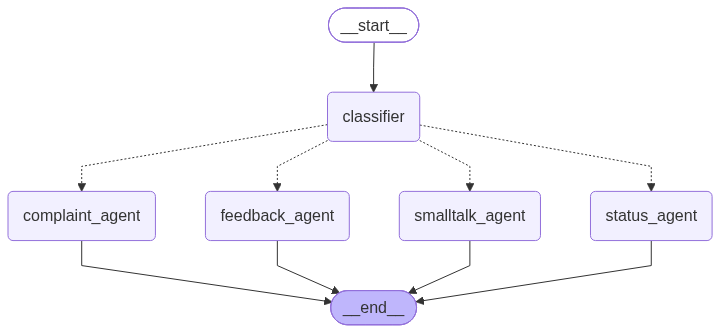

In [20]:
app=ChatbotAgent(OPENAI_API_KEY)
from IPython.display import Image
Image(app.graph.get_graph().draw_mermaid_png())

# Single Message - Graph

In [21]:
import uuid

In [22]:
# Single message
msg_list=[]

user_input="what is the status of my order?."
msg_list.append({"role":"user","content":user_input})
app=ChatbotAgent(OPENAI_API_KEY)
thread_id = uuid.uuid4()
thread={"configurable":{"thread_id":thread_id}}
full_resp = ""
for s in app.graph.stream({'messages': msg_list}, thread):
  for k,v in s.items():
    if resp_gen := v.get("response"):
      print(f"Assistant: ")
      for chunk in resp_gen:
        text = getattr(chunk, "content", None) or getattr(chunk, "delta", None) # or str(chunk)
        if text:
          print(text, end="", flush=True)
          full_resp += text

if full_resp:
  msg_list.append({"role":"assistant","content":full_resp})

Classified category: status_agent
Status agent processing....
Assistant: 
I don’t have any order details for Order ID: 0, so I can’t see the current status.

Please provide a valid order ID (or the email/phone used to place the order), and I’ll fetch the latest status right away. 

Common statuses you might see: Pending, Processing, Shipped, Out for Delivery, Delivered, Cancelled.

If you’d like, I can also set up notifications to keep you updated via email or SMS.

# Chat - Graph

In [23]:
msg_list=[]
while True:
  user_input=input("User: ")
  if(len(user_input)<=0):
    print("\n\n\nGoodbye!!\n\n\n")
    break
  msg_list.append({"role":"user","content":user_input})
  app=ChatbotAgent(OPENAI_API_KEY)
  thread_id = uuid.uuid4()
  thread={"configurable":{"thread_id":thread_id}}
  full_resp = ""
  for s in app.graph.stream({'messages': msg_list}, thread):
    for k,v in s.items():
      if resp_gen := v.get("response"):
        print(f"Assistant: ")
        for chunk in resp_gen:
          text = getattr(chunk, "content", None) or getattr(chunk, "delta", None) # or str(chunk)
          if text:
            print(text, end="", flush=True)
            full_resp += text

  if full_resp:
    msg_list.append({"role":"assistant","content":full_resp})
    print("\n**********\n")

User: What is the status of my order?
Classified category: status_agent
Status agent processing....
Assistant: 
I don’t have any status information for Order ID 0. There are no details on file for that order.

Please provide one of the following so I can look up the status:
- A valid order ID (one you received in a confirmation)
- The email used to place the order or the approximate order date

If you’d like, I can also guide you to your confirmation email or tracking link. I can then tell you the current status (e.g., processing, shipped, out for delivery) and the next steps.
**********

User: 3
Classified category: status_agent
Status agent processing....
Assistant: 
Order 3 status: Lost.

Next steps:
- Please call 1-800-123-4567 to start a lost package investigation with our team.
- We can discuss options (replacement or refund) after the investigation.
- Have your order ID (3) ready. It helps to have your shipping address, order date, and item details if possible.
**********

User: